<a href="https://colab.research.google.com/github/RazyAnas/MachineLearning/blob/main/Multivariant_Imputation_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Working
- fill with most similar rows
- each row can be treated as coordinate if there are 4 features - 4 D coordinate.
- Calculate distance of the missing data neighbour to the others

Steps:
- K nearest neighbours - euclidean
- find the value

Formula:
- underrot of x2-x1 ka square + y2-y1  ka square
- problem is some values can be mising also for the other rows
- we use nan_euclidean - envovles weight

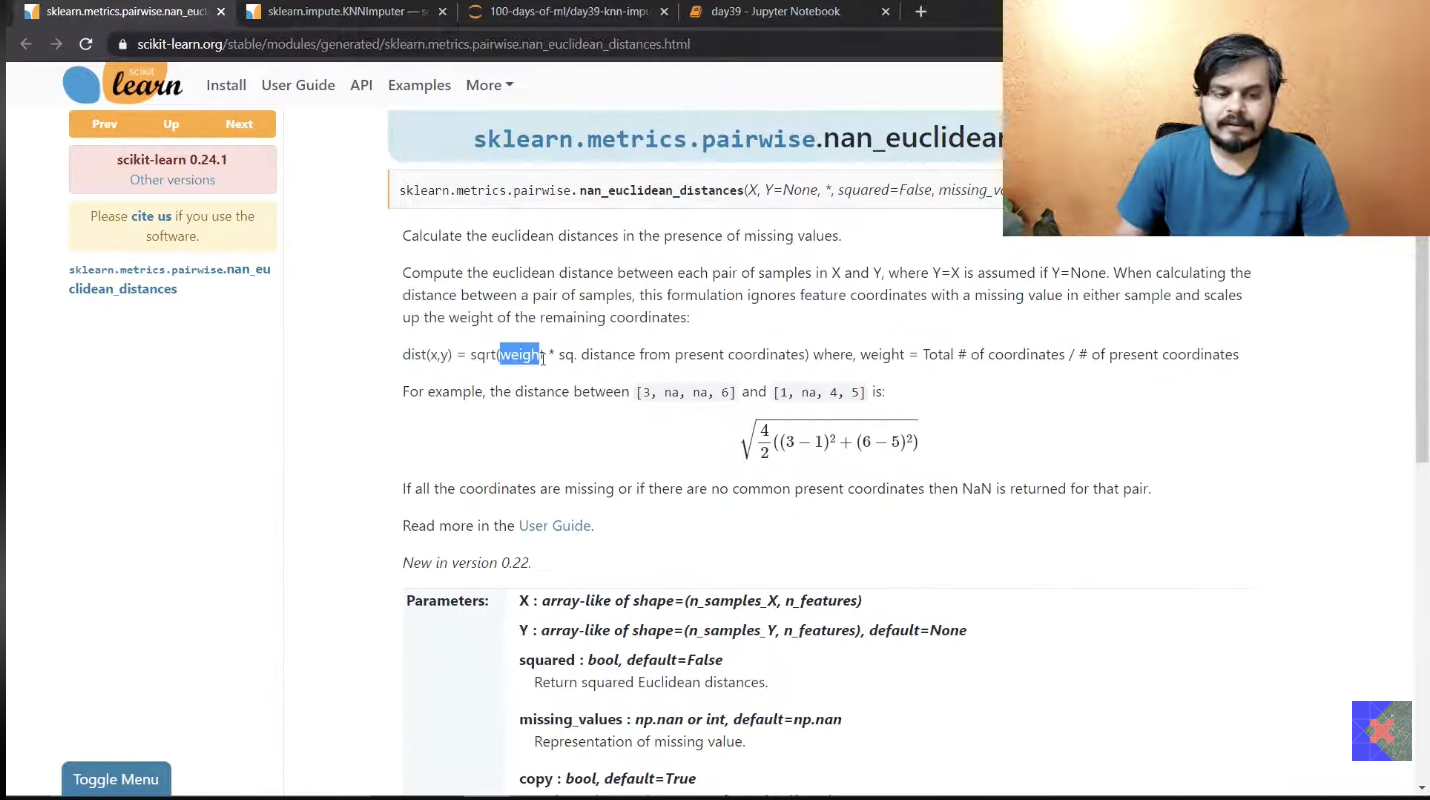

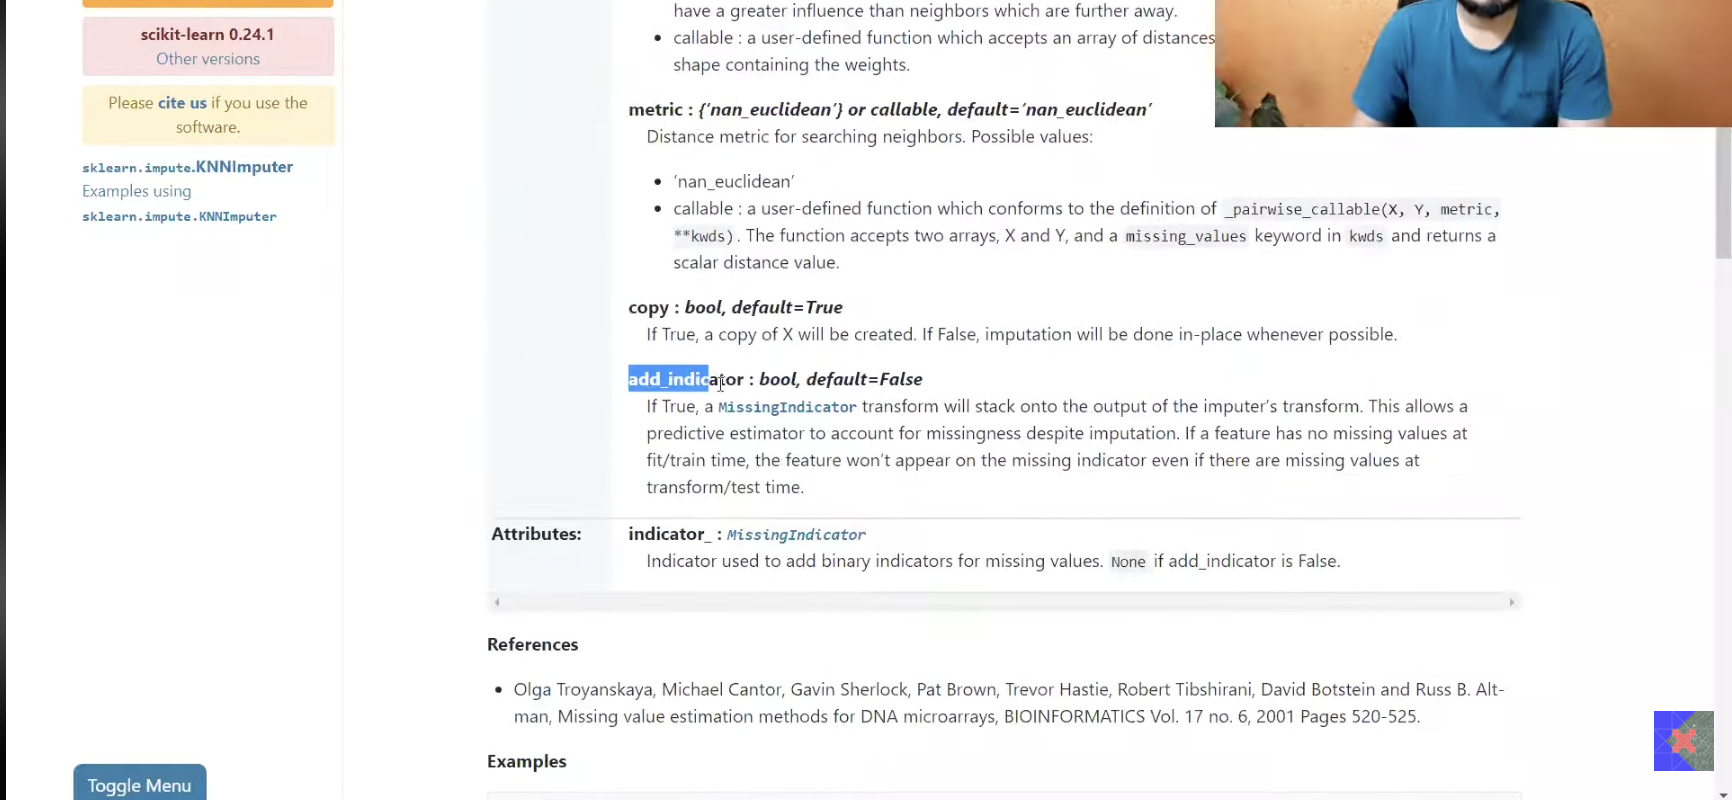

## Advantage and disadvantage
- More accurate
- Lengthy Calculations
- Deployed in production put training set in server
- memory badh jata h speed slow

In [69]:
import pandas as pd
import numpy as np

In [70]:
from sklearn.model_selection import train_test_split

from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score

In [71]:
df = pd.read_csv('https://raw.githubusercontent.com/campusx-official/100-days-of-machine-learning/refs/heads/main/day39-knn-imputer/train.csv', usecols=['Age', 'Pclass', 'Fare', 'Survived'])

In [72]:
df.head()

,Survived,Pclass,Age,Fare
0,0,3,22.0,7.2500
1,1,1,38.0,71.2833
2,1,3,26.0,7.9250
3,1,1,35.0,53.1000
4,0,3,35.0,8.0500


In [73]:
df.isnull().mean() *100

,0
Survived,0.00000
Pclass,0.00000
Age,19.86532
Fare,0.00000


In [74]:
X = df.drop (columns=['Survived' ])
y = df['Survived']
X_train,X_test,y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=2)
X_train. head()

,Pclass,Age,Fare
30,1,40.0,27.7208
10,3,4.0,16.7000
873,3,47.0,9.0000
182,3,9.0,31.3875
876,3,20.0,9.8458


In [75]:
knn = KNNImputer(n_neighbors=5, weights='distance')

In [76]:
X_train_trf = knn.fit_transform(X_train)
X_test_trf = knn.transform(X_test)

In [77]:
pd.DataFrame(X_train_trf, columns=X_train.columns)

,Pclass,Age,Fare
0,1.0,40.000000,27.7208
1,3.0,4.000000,16.7000
2,3.0,47.000000,9.0000
3,3.0,9.000000,31.3875
4,3.0,20.000000,9.8458
...,...,...,...
707,3.0,30.000000,8.6625
708,3.0,25.047962,8.7125
709,1.0,71.000000,49.5042
710,1.0,29.530076,221.7792


In [78]:
lr = LogisticRegression()

lr.fit(X_train_trf, y_train)
y_pred = lr.predict(X_test_trf)

accuracy_score(y_test, y_pred)

0.7039106145251397

In [79]:
# Comparision with Simple Imputer --> Mean

si = SimpleImputer()

X_train_trf2 = si.fit_transform(X_train)
X_test_trf2 = si.transform(X_test)

In [81]:
lr = LogisticRegression()

lr.fit(X_train_trf2, y_train)
y_pred2 = lr.predict(X_test_trf2)

accuracy_score(y_test, y_pred2)

0.6927374301675978